In [2]:
# pip install scikit-learn matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [3]:
iris = datasets.load_iris()
X, y = iris.data, iris.target
names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train.shape, X_test.shape, np.bincount(y), np.bincount(y_train), np.bincount(y_test)

((112, 4),
 (38, 4),
 array([50, 50, 50]),
 array([38, 37, 37]),
 array([12, 13, 13]))

Test accuracy (k=5): 0.921
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38



Test accuracy (k=5): 0.921
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38



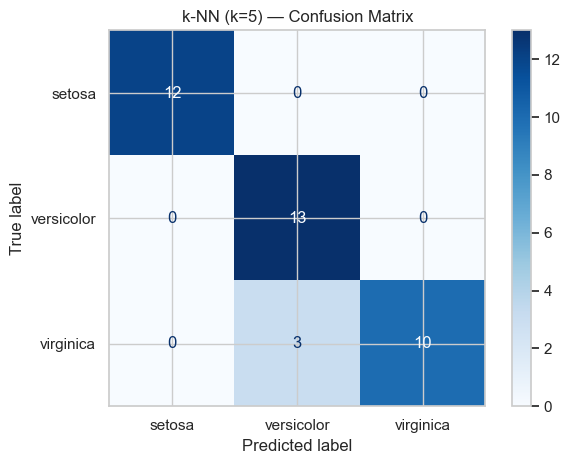

In [4]:
#Train a baseline k‑NN (k=5)
knn5 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn5.fit(X_train, y_train)

y_pred = knn5.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy (k=5):", round(acc, 3))
print(classification_report(y_test, y_pred, target_names=names))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=names)\
    .plot(cmap='Blues'); plt.title('k-NN (k=5) — Confusion Matrix'); plt.tight_layout(); plt.show()

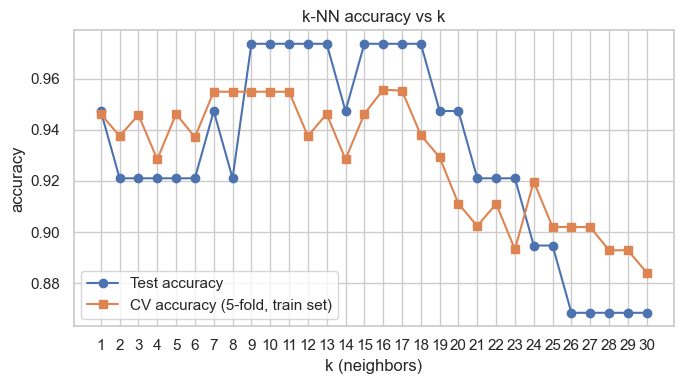

(16, 9)

In [5]:
#How does accuracy change with k?
ks = range(1, 31)
test_acc = []
cv_acc = []
for k in ks:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    pipe.fit(X_train, y_train)
    test_acc.append(accuracy_score(y_test, pipe.predict(X_test)))
    # 5-fold CV on the **training** set
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_acc.append(cv.mean())

plt.figure(figsize=(7,4))
plt.plot(ks, test_acc, marker='o', label='Test accuracy')
plt.plot(ks, cv_acc, marker='s', label='CV accuracy (5-fold, train set)')
plt.xticks(list(ks)); plt.xlabel('k (neighbors)'); plt.ylabel('accuracy')
plt.title('k-NN accuracy vs k'); plt.legend(); plt.tight_layout(); plt.show()

best_k_cv = ks[int(np.argmax(cv_acc))]
best_k_test = ks[int(np.argmax(test_acc))]
best_k_cv, best_k_test

In [6]:
#Distance metric & weighting
#Compare Euclidean vs Manhattan; uniform vs distance weighting.
configs = [
    ('euclidean','uniform'),
    ('euclidean','distance'),
    ('manhattan','uniform'),
    ('manhattan','distance'),
]
summary = []
for metric, w in configs:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_cv, metric=metric, weights=w))
    pipe.fit(X_train, y_train)
    yhat = pipe.predict(X_test)
    summary.append((metric, w, accuracy_score(y_test, yhat)))
summary

[('euclidean', 'uniform', 0.9736842105263158),
 ('euclidean', 'distance', 0.9736842105263158),
 ('manhattan', 'uniform', 0.9473684210526315),
 ('manhattan', 'distance', 0.9473684210526315)]

In [11]:
# Search over k in {3,7,11} and (metric, weights) and report best triple on test set
ks = [3, 7, 11]
metrics = ['euclidean', 'manhattan']
weights = ['uniform', 'distance']
results = []
best = (None, None, None, 0.0)  # (metric, weights, k, acc)
for k in ks:
    for metric in metrics:
        for w in weights:
            pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k, metric=metric, weights=w))
            pipe.fit(X_train, y_train)
            yhat = pipe.predict(X_test)
            acc = accuracy_score(y_test, yhat)
            results.append((metric, w, k, acc))
            if acc > best[3]:
                best = (metric, w, k, acc)

# Print sorted results (best first) and the best triple
print('Results (metric, weights, k, test_acc):')
for r in sorted(results, key=lambda x: -x[3]):
    print(f'{r[0]:10s} | {r[1]:8s} | k={r[2]:2d} | acc={r[3]:.3f}')

print('Best on test set:')
print(f'metric={best[0]}, weights={best[1]}, k={best[2]}, test_acc={best[3]:.3f}')

Results (metric, weights, k, test_acc):
euclidean  | distance | k= 7 | acc=0.974
manhattan  | distance | k= 7 | acc=0.974
euclidean  | uniform  | k=11 | acc=0.974
euclidean  | distance | k=11 | acc=0.974
manhattan  | uniform  | k=11 | acc=0.974
manhattan  | distance | k=11 | acc=0.974
euclidean  | distance | k= 3 | acc=0.947
manhattan  | uniform  | k= 3 | acc=0.947
manhattan  | distance | k= 3 | acc=0.947
euclidean  | uniform  | k= 7 | acc=0.947
manhattan  | uniform  | k= 7 | acc=0.947
euclidean  | uniform  | k= 3 | acc=0.921
Best on test set:
metric=euclidean, weights=distance, k=7, test_acc=0.974


Final k=16 | Test accuracy=0.974


Final k=16 | Test accuracy=0.974


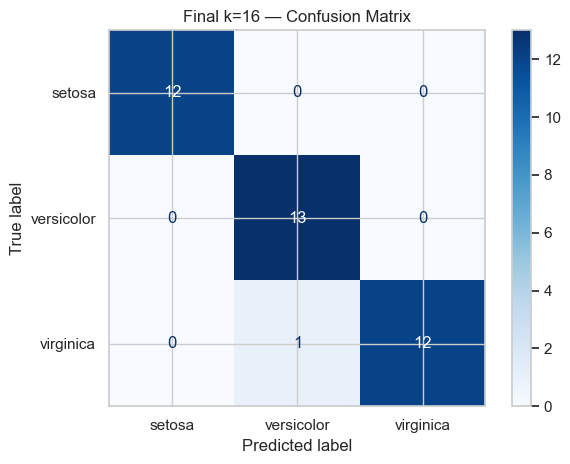

In [7]:
#Final model (use CV‑chosen k) + confusion matrix
final_k = best_k_cv
final = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=final_k))
final.fit(X_train, y_train)
y_pred = final.predict(X_test)

print(f"Final k={final_k} | Test accuracy={accuracy_score(y_test, y_pred):.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=names)\
    .plot(cmap='Blues'); plt.title(f'Final k={final_k} — Confusion Matrix'); plt.tight_layout(); plt.show()

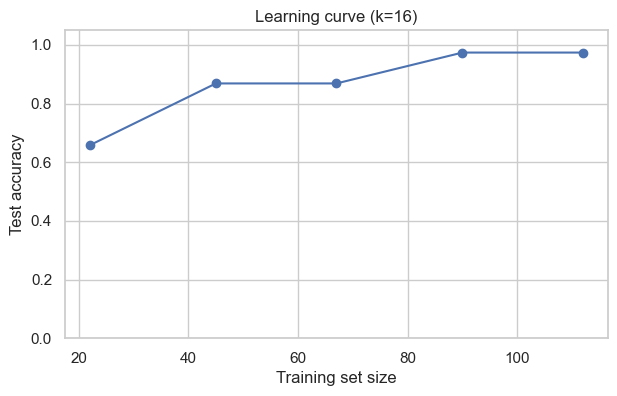

In [14]:
# Learning curve: for k=best_k_cv, train on fractions of training data and plot test accuracy vs training size
try:
    k_lc = best_k_cv
except NameError:
    try:
        k_lc = best_k_test
    except NameError:
        k_lc = 5

from sklearn.model_selection import StratifiedShuffleSplit
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
train_sizes = []
test_accuracies = []
n_samples = len(X_train)
for frac in fractions:
    if frac >= 1.0:
        X_sub, y_sub = X_train, y_train
    else:
        n_train = max(1, int(round(n_samples * frac)))
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_train, random_state=42)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train[train_idx], y_train[train_idx]
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_lc))
    model.fit(X_sub, y_sub)
    yhat = model.predict(X_test)
    train_sizes.append(len(X_sub))
    test_accuracies.append(accuracy_score(y_test, yhat))

plt.figure(figsize=(7,4))
plt.plot(train_sizes, test_accuracies, marker='o')
plt.xlabel('Training set size')
plt.ylabel('Test accuracy')
plt.title(f'Learning curve (k={k_lc})')
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

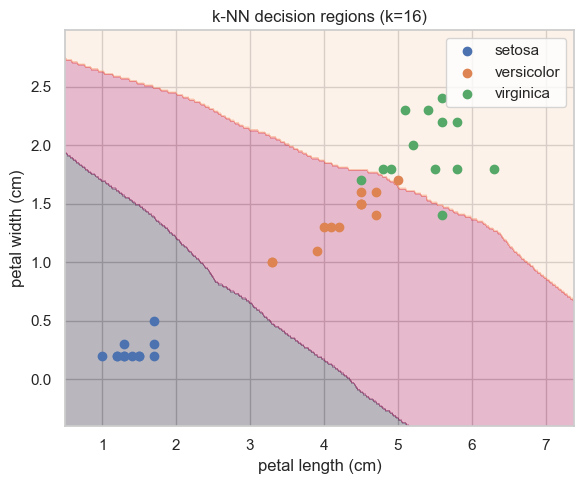

In [8]:
#(Optional) 2‑feature decision regions
#Visualize boundaries with two features (petal length & width).
feat_idx = [2, 3]  # petal length, petal width
X2 = X[:, feat_idx]
X2_tr, X2_te, y_tr, y_te = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)

pipe2 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=final_k))
pipe2.fit(X2_tr, y_tr)

# meshgrid
h = 0.02
x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = pipe2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
for i, lab in enumerate(names):
    pts = X2_te[y_te==i]
    plt.scatter(pts[:,0], pts[:,1], label=lab)
plt.xlabel(iris.feature_names[feat_idx[0]]); plt.ylabel(iris.feature_names[feat_idx[1]])
plt.title(f'k-NN decision regions (k={final_k})'); plt.legend(); plt.tight_layout(); plt.show()

In [12]:
# Feature-scaling ablation: compare k-NN with and without StandardScaler
try:
    k_use = final_k
except NameError:
    try:
        k_use = best_k_cv
    except NameError:
        k_use = 5

# With scaling
pipe_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_use))
pipe_scaled.fit(X_train, y_train)
acc_scaled = accuracy_score(y_test, pipe_scaled.predict(X_test))

# Without scaling (raw features)
clf_noscale = KNeighborsClassifier(n_neighbors=k_use)
clf_noscale.fit(X_train, y_train)
acc_noscale = accuracy_score(y_test, clf_noscale.predict(X_test))

print(f'k={k_use} | with StandardScaler: {acc_scaled:.3f} | without scaling: {acc_noscale:.3f}')

# Short explanation
if acc_scaled == acc_noscale:
    print('No change: features are already on comparable scales for this dataset.')
elif acc_scaled > acc_noscale:
    print('Scaling helps: k-NN is distance-based so unscaled features with larger ranges can dominate distances, hurting performance.')
else:
    print('Unexpected: unscaled performed better — inspect features and consider if scaling removed useful scale information.')

k=16 | with StandardScaler: 0.974 | without scaling: 0.947
Scaling helps: k-NN is distance-based so unscaled features with larger ranges can dominate distances, hurting performance.


In [15]:
# Estimate accuracy distribution with 10-fold StratifiedKFold on the full dataset for k=best_k_cv
try:
    k_cv_eval = best_k_cv
except NameError:
    try:
        k_cv_eval = best_k_test
    except NameError:
        k_cv_eval = 5

from sklearn.model_selection import StratifiedKFold, cross_val_score
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_cv_eval))
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f'k={k_cv_eval} | 10-fold Stratified CV: mean={scores.mean():.3f} ± {scores.std():.3f}')
print('fold scores:', np.round(scores, 3))

k=16 | 10-fold Stratified CV: mean=0.960 ± 0.053
fold scores: [1.    1.    1.    0.933 0.867 0.933 1.    1.    1.    0.867]


### How did increasing k change bias/variance?

- Increasing `k` increases bias and reduces variance: larger neighborhoods smooth decision boundaries.
- Signs to look for:
  - **High variance (small k):** very high training accuracy but noticeably lower test/CV accuracy (large train–test gap).
  - **High bias (large k):** both training and test accuracies are low (underfitting); curves flatten and near each other.
- In the plots above: a falling training accuracy with increasing `k` plus a CV/test accuracy that first rises then falls indicates moving from variance-dominated to bias-dominated regimes.
- Practical rule: choose the `k` at which CV/test accuracy peaks (best trade-off between bias and variance).

### Which distance/weighting worked best — does that match the decision‑region plot intuition?

- Check the `summary` output (and the printed results from the metric/weight search) to see which `(metric, weights)` achieved the highest test accuracy.
- Interpretation guidance:
  - If `distance` weighting is best: nearer neighbors got more influence, so decision regions in the plot will be more locally adaptive and may wrap tightly around groups of points.
  - If `uniform` weighting is best: all neighbors vote equally, producing smoother, less locally-sensitive boundaries.
  - If `manhattan` (L1) beats `euclidean` (L2): expect axis-aligned / diamond-like influence shapes in local neighborhoods versus rounder boundaries for Euclidean.
- To verify the match: compare the best `(metric, weights)` reported above to the two‑feature decision‑region plot — the geometric style of boundaries (round vs diamond/axis-aligned) and the local sharpness (tight clusters vs smooth regions) should reflect the winning choice.
- Conclusion: use the printed best triple as the empirical answer, and use the decision‑region visualization to confirm the geometric intuition described above.

### Why is scaling crucial for k‑NN, and when might it matter less?

- k‑NN relies on distances: features with larger numeric ranges can dominate neighbor selection and distort results.
- Scaling (e.g., `StandardScaler` or `MinMaxScaler`) brings features to comparable ranges so each feature contributes appropriately to distances.
- When scaling matters most: when features have different units (e.g., meters vs kilograms), vastly different variances, or when using Euclidean/L2 distances.
- When scaling matters less: when all features are already on similar scales, when using features that are categorical/one‑hot, or when using models/metrics that are invariant to scale.
- Practical notes: fit scalers on the training set only; outliers affect standard scaling (consider `RobustScaler` if needed).